# Interest Rate Volatility Surfaces Tutorial

This tutorial demonstrates how to construct and visualize interest rate volatility surfaces in QuantStrata:

1. **Swaption Vol Cube**: 3D surface (expiry × tenor × strike)
2. **Cap/Floor Vol Surface**: 2D surface (expiry × strike)

These surfaces are essential for pricing IR derivatives like swaptions, caps, and floors.

In [3]:
# Standard imports
import sys
sys.path.insert(0, '../../..')

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from src.marketdata.surfaces import (
    SwaptionVolCube,
    FlatSwaptionVolCube,
    CapFloorVolSurface,
    FlatCapFloorVolSurface,
    create_atm_swaption_vol_cube,
    create_cap_vol_surface_from_term_structure,
)

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

## 1. Swaption Volatility Cube

A swaption vol cube is a 3D structure where volatility depends on:
- **Option Expiry**: When the swaption can be exercised
- **Swap Tenor**: Length of the underlying swap
- **Strike**: The fixed rate of the underlying swap

### 1.1 Creating a Realistic Swaption Vol Cube

In [4]:
# Define grid points
expiries = np.array([0.25, 0.5, 1.0, 2.0, 5.0, 10.0])  # Option expiries in years
tenors = np.array([1.0, 2.0, 5.0, 10.0, 30.0])         # Swap tenors in years
strikes = np.array([0.01, 0.02, 0.025, 0.03, 0.035, 0.04, 0.05])  # Strike rates

print(f"Expiries: {expiries}")
print(f"Tenors: {tenors}")
print(f"Strikes: {strikes * 100}%")

Expiries: [ 0.25  0.5   1.    2.    5.   10.  ]
Tenors: [ 1.  2.  5. 10. 30.]
Strikes: [1.  2.  2.5 3.  3.5 4.  5. ]%


In [5]:
# Create realistic vol cube with:
# - Term structure effect (vol decreases with expiry)
# - Tenor effect (vol increases with tenor)
# - Smile effect (vol higher away from ATM)

atm_strike = 0.03  # 3% ATM
base_vol = 0.0050  # 50bp base normal vol

vols = np.zeros((len(expiries), len(tenors), len(strikes)))

for i, exp in enumerate(expiries):
    for j, ten in enumerate(tenors):
        for k, strike in enumerate(strikes):
            # Term structure: vol decreases with sqrt(expiry)
            term_effect = base_vol / np.sqrt(exp + 0.5)
            
            # Tenor effect: longer tenors have higher vol
            tenor_effect = 0.0005 * np.log(ten + 1)
            
            # Smile effect: quadratic in strike distance from ATM
            smile_effect = 50 * (strike - atm_strike) ** 2
            
            # Skew: negative skew (lower strikes have higher vol)
            skew_effect = -0.05 * (strike - atm_strike)
            
            vols[i, j, k] = term_effect + tenor_effect + smile_effect + skew_effect

# Create the swaption vol cube
swaption_cube = SwaptionVolCube(
    expiries=expiries,
    tenors=tenors,
    strikes=strikes,
    vols=vols,
    vol_type="normal",  # Bachelier vol (bp)
)

print(f"Cube shape: {swaption_cube.vols.shape}")
print(f"Vol type: {swaption_cube.vol_type}")

Cube shape: (6, 5, 7)
Vol type: normal


### 1.2 Querying the Swaption Vol Cube

In [6]:
# Query specific points
test_cases = [
    (1.0, 5.0, 0.03),   # 1Y x 5Y ATM
    (5.0, 10.0, 0.03),  # 5Y x 10Y ATM
    (2.0, 5.0, 0.02),   # 2Y x 5Y at 2% strike (in-the-money payer)
    (2.0, 5.0, 0.04),   # 2Y x 5Y at 4% strike (out-of-the-money payer)
]

print("Swaption Volatilities (Normal Vol in bp):")
print("-" * 50)
for exp, ten, strike in test_cases:
    vol = swaption_cube.implied_vol(exp, ten, strike)
    print(f"{exp:.0f}Y x {ten:.0f}Y @ {strike*100:.1f}%: {vol * 10000:.1f} bp")

Swaption Volatilities (Normal Vol in bp):
--------------------------------------------------
1Y x 5Y @ 3.0%: 49.8 bp
5Y x 10Y @ 3.0%: 33.3 bp
2Y x 5Y @ 2.0%: 95.6 bp
2Y x 5Y @ 4.0%: 85.6 bp


In [7]:
# Get ATM volatility matrix
print("\nATM Normal Vol Matrix (bp):")
print("-" * 60)
print(f"{'Expiry':>8}", end="")
for ten in tenors:
    print(f"{ten:.0f}Y".rjust(10), end="")
print()

for exp in expiries:
    print(f"{exp:.2f}Y".rjust(8), end="")
    for ten in tenors:
        vol = swaption_cube.atm_vol(exp, ten)
        print(f"{vol * 10000:.1f}".rjust(10), end="")
    print()


ATM Normal Vol Matrix (bp):
------------------------------------------------------------
  Expiry        1Y        2Y        5Y       10Y       30Y
   0.25Y      61.2      63.2      66.7      69.7      74.9
   0.50Y      53.5      55.5      59.0      62.0      67.2
   1.00Y      44.3      46.3      49.8      52.8      58.0
   2.00Y      35.1      37.1      40.6      43.6      48.8
   5.00Y      24.8      26.8      30.3      33.3      38.5
  10.00Y      18.9      20.9      24.4      27.4      32.6


### 1.3 Visualizing the Swaption Vol Cube

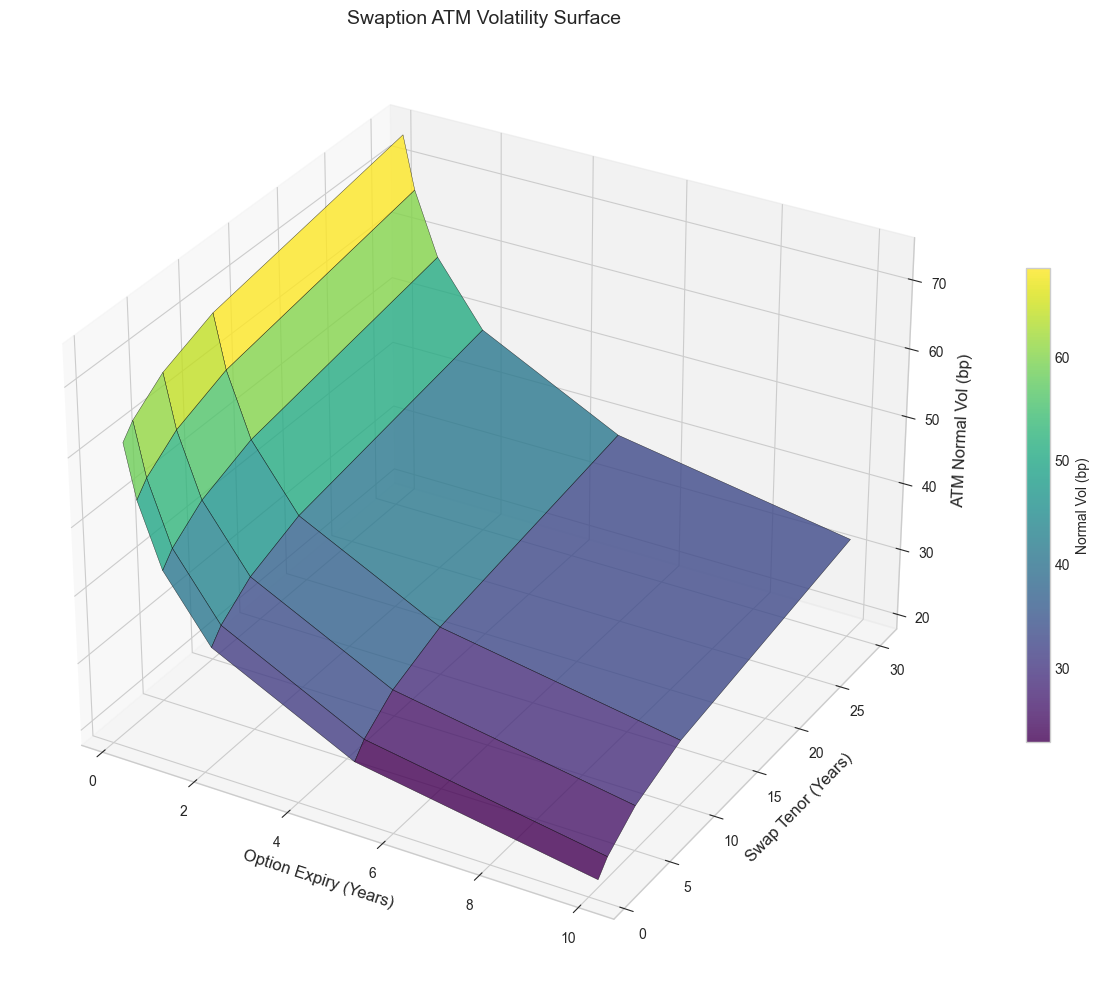

In [8]:
# Plot ATM surface (expiry vs tenor)
fig = plt.figure(figsize=(14, 10))

# Create meshgrid for plotting
exp_mesh, ten_mesh = np.meshgrid(expiries, tenors, indexing='ij')

# Get ATM vols
atm_vols = np.zeros((len(expiries), len(tenors)))
for i, exp in enumerate(expiries):
    for j, ten in enumerate(tenors):
        atm_vols[i, j] = swaption_cube.atm_vol(exp, ten)

# 3D surface plot
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(
    exp_mesh, ten_mesh, atm_vols * 10000,
    cmap='viridis', alpha=0.8, edgecolor='k', linewidth=0.3
)
ax.set_xlabel('Option Expiry (Years)', fontsize=12)
ax.set_ylabel('Swap Tenor (Years)', fontsize=12)
ax.set_zlabel('ATM Normal Vol (bp)', fontsize=12)
ax.set_title('Swaption ATM Volatility Surface', fontsize=14)
fig.colorbar(surf, ax=ax, shrink=0.5, label='Normal Vol (bp)')
plt.tight_layout()
plt.show()

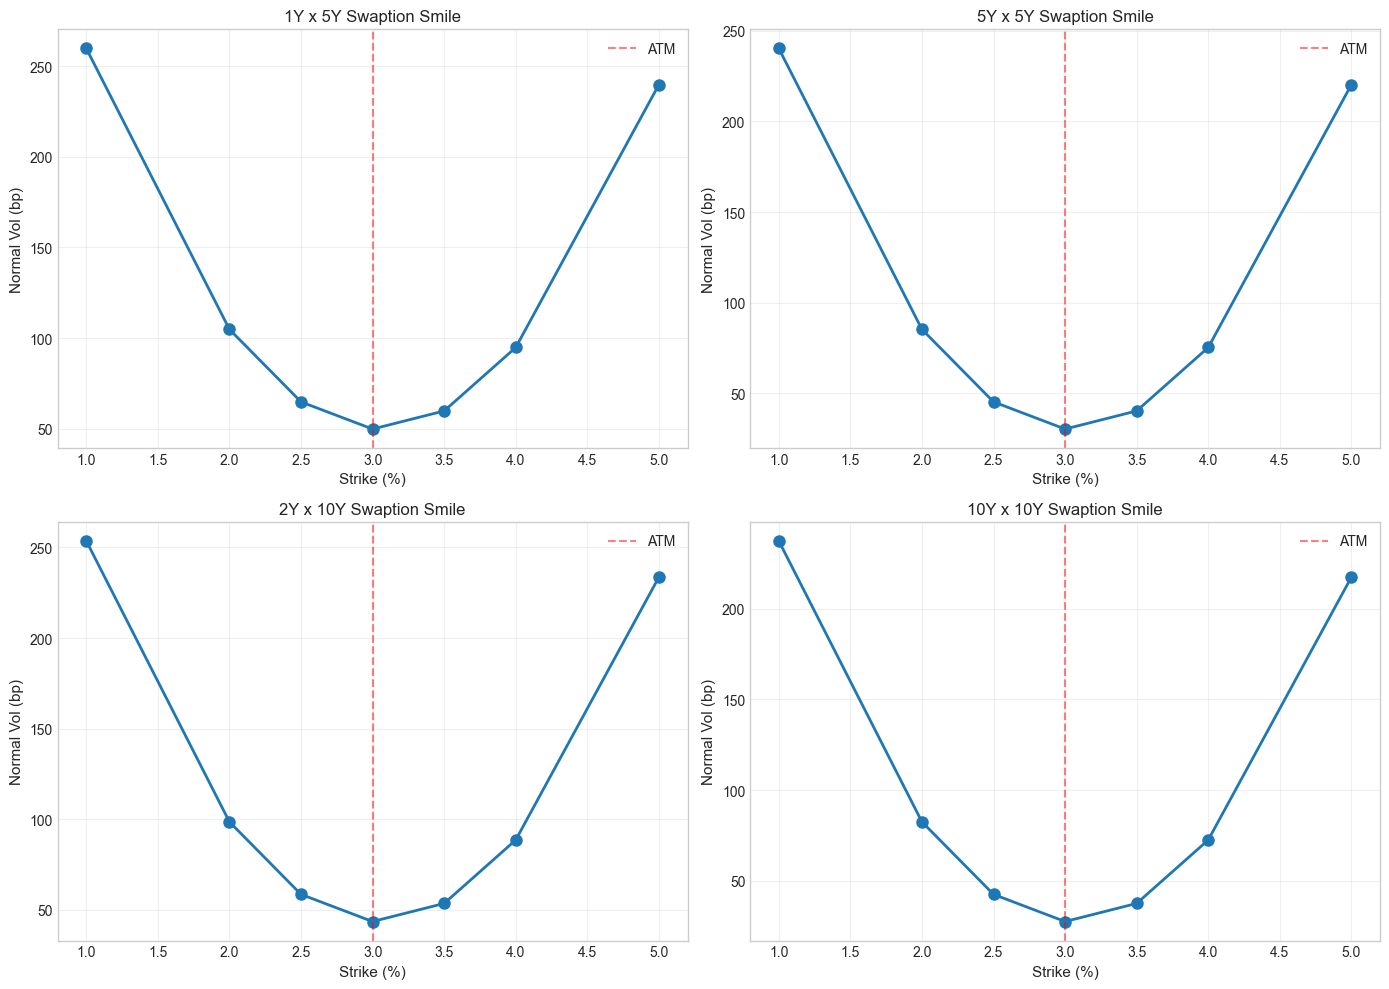

In [9]:
# Plot volatility smiles for different expiry/tenor combinations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

smile_configs = [
    (1.0, 5.0, "1Y x 5Y"),
    (5.0, 5.0, "5Y x 5Y"),
    (2.0, 10.0, "2Y x 10Y"),
    (10.0, 10.0, "10Y x 10Y"),
]

for ax, (exp, ten, label) in zip(axes.flat, smile_configs):
    strikes_plot, vols_plot = swaption_cube.smile(exp, ten)
    ax.plot(strikes_plot * 100, vols_plot * 10000, 'o-', linewidth=2, markersize=8)
    ax.axvline(x=atm_strike * 100, color='r', linestyle='--', alpha=0.5, label='ATM')
    ax.set_xlabel('Strike (%)', fontsize=11)
    ax.set_ylabel('Normal Vol (bp)', fontsize=11)
    ax.set_title(f'{label} Swaption Smile', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

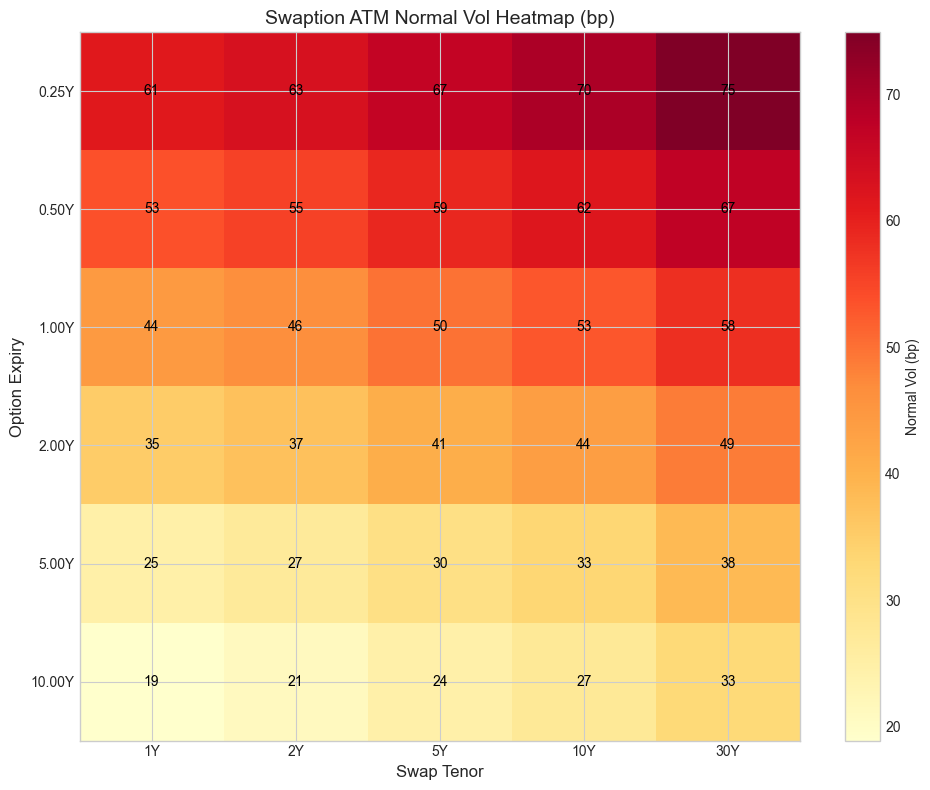

In [10]:
# Heatmap of ATM volatilities
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(atm_vols * 10000, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(tenors)))
ax.set_xticklabels([f'{t:.0f}Y' for t in tenors])
ax.set_yticks(range(len(expiries)))
ax.set_yticklabels([f'{e:.2f}Y' for e in expiries])
ax.set_xlabel('Swap Tenor', fontsize=12)
ax.set_ylabel('Option Expiry', fontsize=12)
ax.set_title('Swaption ATM Normal Vol Heatmap (bp)', fontsize=14)

# Add text annotations
for i in range(len(expiries)):
    for j in range(len(tenors)):
        ax.text(j, i, f'{atm_vols[i, j] * 10000:.0f}',
                ha='center', va='center', color='black', fontsize=10)

fig.colorbar(im, ax=ax, label='Normal Vol (bp)')
plt.tight_layout()
plt.show()

### 1.4 Using the Factory Function

In [11]:
# Create cube from ATM vols with parameterized smile
atm_vols_input = np.array([
    [0.0060, 0.0055, 0.0050],  # 1Y expiry
    [0.0055, 0.0050, 0.0048],  # 2Y expiry
    [0.0050, 0.0048, 0.0045],  # 5Y expiry
])

cube_from_atm = create_atm_swaption_vol_cube(
    expiries=np.array([1.0, 2.0, 5.0]),
    tenors=np.array([2.0, 5.0, 10.0]),
    atm_vols=atm_vols_input,
    smile_width=0.01,       # ±100bp strike range
    smile_curvature=0.5,    # Quadratic smile coefficient
    vol_type="normal",
)

print(f"Created cube with {len(cube_from_atm.strikes)} strike points")
print(f"Strike range: {cube_from_atm.strikes.min()*100:.0f}bp to {cube_from_atm.strikes.max()*100:.0f}bp")

Created cube with 9 strike points
Strike range: -1bp to 1bp


## 2. Cap/Floor Volatility Surface

A cap/floor vol surface is a 2D structure where volatility depends on:
- **Cap Expiry**: Maturity of the cap/floor
- **Strike**: The cap/floor rate

### 2.1 Creating a Cap/Floor Vol Surface

In [12]:
# Define grid
cap_expiries = np.array([0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0])
cap_strikes = np.array([0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05])

# Create realistic cap vol surface
# - Hump-shaped term structure (peak around 2-3Y)
# - Smile effect

cap_atm_strike = 0.03
cap_base_vol = 0.0055

cap_vols = np.zeros((len(cap_expiries), len(cap_strikes)))

for i, exp in enumerate(cap_expiries):
    for j, strike in enumerate(cap_strikes):
        # Hump-shaped term structure
        hump = cap_base_vol * (1 + 0.3 * np.exp(-0.5 * (exp - 2.5)**2))
        
        # Smile
        smile = 30 * (strike - cap_atm_strike) ** 2
        
        # Skew (mild negative)
        skew = -0.03 * (strike - cap_atm_strike)
        
        cap_vols[i, j] = hump + smile + skew

cap_surface = CapFloorVolSurface(
    expiries=cap_expiries,
    strikes=cap_strikes,
    vols=cap_vols,
    vol_type="normal",
)

print(f"Cap/Floor surface shape: {cap_surface.vols.shape}")

Cap/Floor surface shape: (7, 9)


In [13]:
# Query the surface
print("Cap/Floor Volatilities (Normal Vol in bp):")
print("-" * 40)
for exp in [1.0, 2.0, 5.0, 10.0]:
    vol = cap_surface.implied_vol(exp, cap_atm_strike)
    print(f"{exp:.0f}Y Cap ATM: {vol * 10000:.1f} bp")

Cap/Floor Volatilities (Normal Vol in bp):
----------------------------------------
1Y Cap ATM: 60.4 bp
2Y Cap ATM: 69.6 bp
5Y Cap ATM: 55.7 bp
10Y Cap ATM: 55.0 bp


### 2.2 Visualizing the Cap/Floor Surface

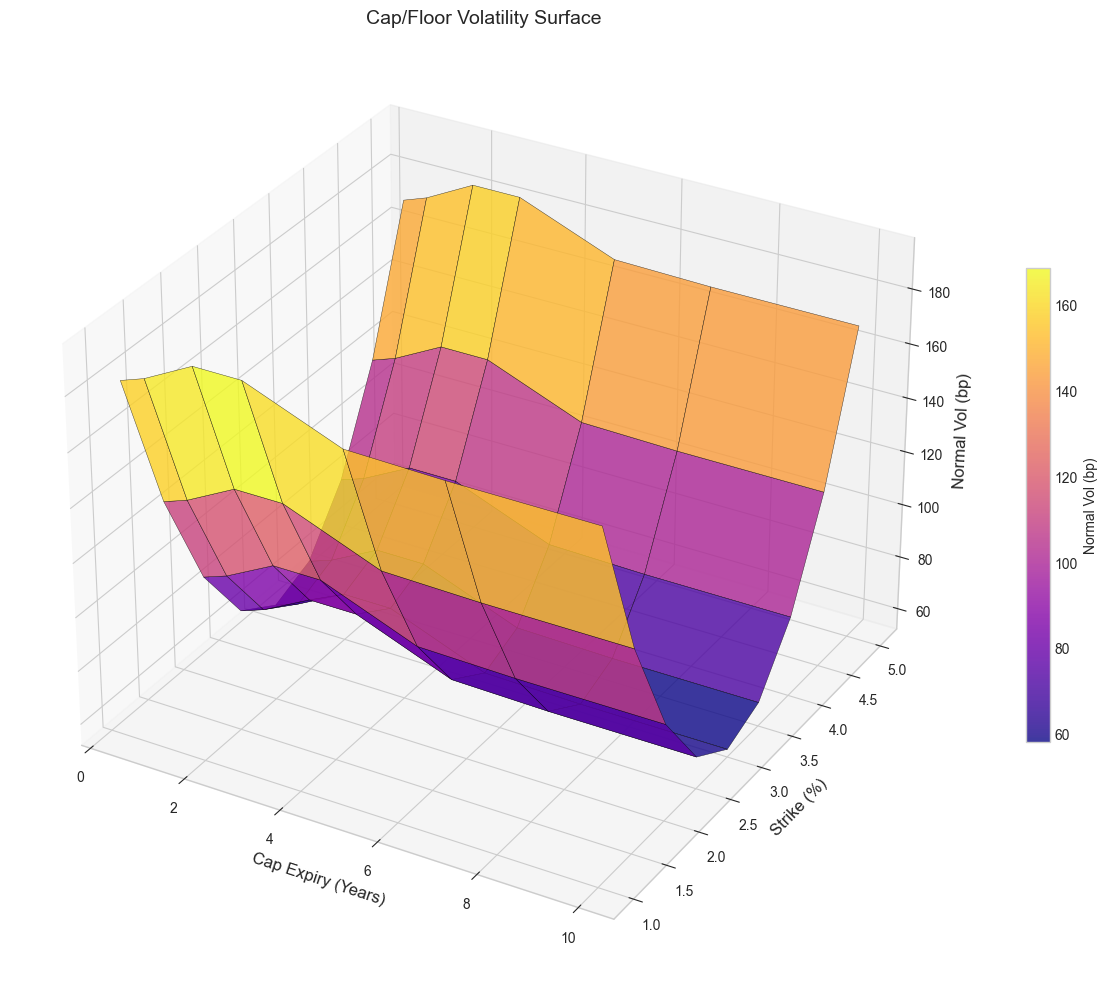

In [14]:
# 3D surface plot
fig = plt.figure(figsize=(14, 10))

exp_mesh, strike_mesh = np.meshgrid(cap_expiries, cap_strikes, indexing='ij')

ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(
    exp_mesh, strike_mesh * 100, cap_vols * 10000,
    cmap='plasma', alpha=0.8, edgecolor='k', linewidth=0.3
)
ax.set_xlabel('Cap Expiry (Years)', fontsize=12)
ax.set_ylabel('Strike (%)', fontsize=12)
ax.set_zlabel('Normal Vol (bp)', fontsize=12)
ax.set_title('Cap/Floor Volatility Surface', fontsize=14)
fig.colorbar(surf, ax=ax, shrink=0.5, label='Normal Vol (bp)')
plt.tight_layout()
plt.show()

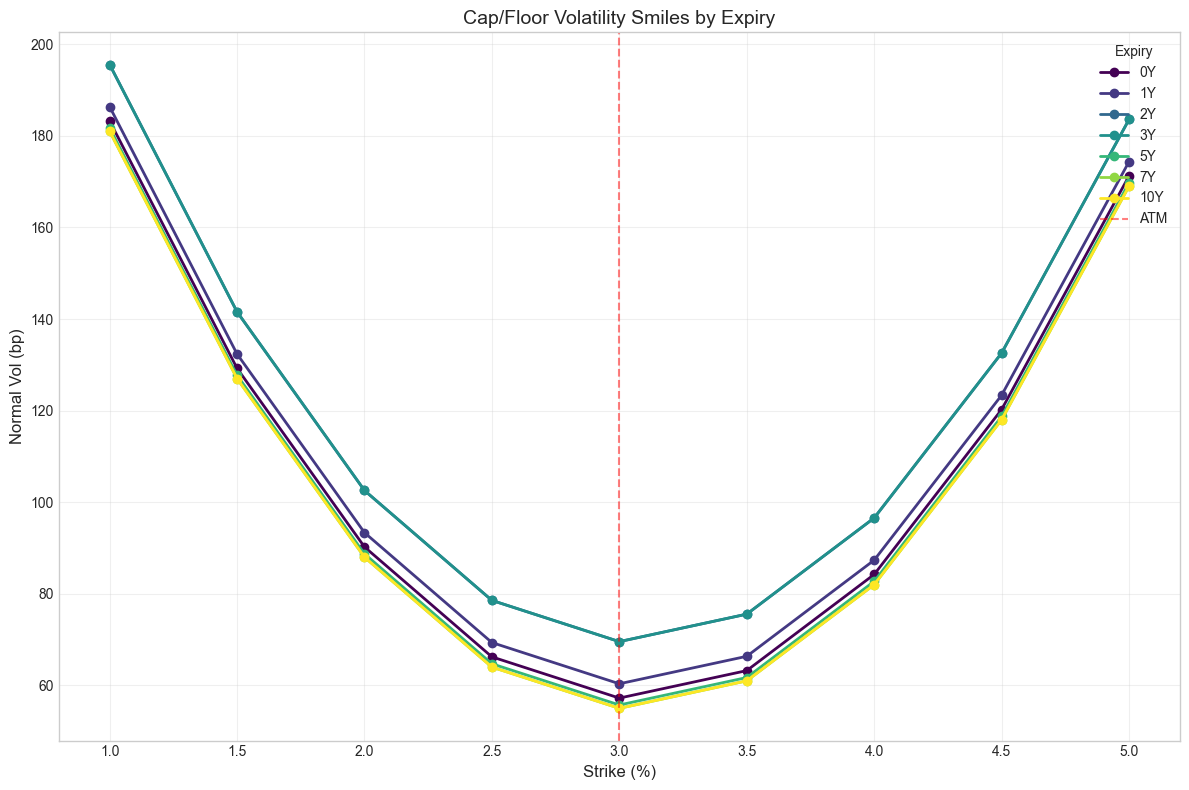

In [15]:
# Plot cap vol smiles at different expiries
fig, ax = plt.subplots(figsize=(12, 8))

colors = plt.cm.viridis(np.linspace(0, 1, len(cap_expiries)))

for i, exp in enumerate(cap_expiries):
    strikes_plot, vols_plot = cap_surface.smile(exp)
    ax.plot(strikes_plot * 100, vols_plot * 10000, 'o-',
            color=colors[i], linewidth=2, markersize=6, label=f'{exp:.0f}Y')

ax.axvline(x=cap_atm_strike * 100, color='r', linestyle='--', alpha=0.5, label='ATM')
ax.set_xlabel('Strike (%)', fontsize=12)
ax.set_ylabel('Normal Vol (bp)', fontsize=12)
ax.set_title('Cap/Floor Volatility Smiles by Expiry', fontsize=14)
ax.legend(title='Expiry', loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

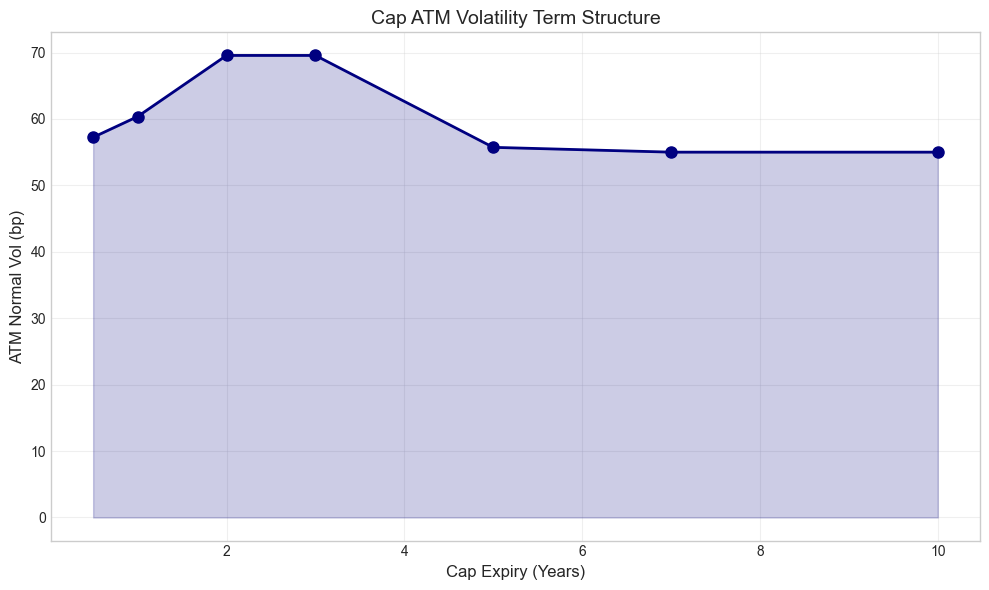

In [16]:
# ATM term structure
fig, ax = plt.subplots(figsize=(10, 6))

atm_term_structure = [cap_surface.implied_vol(exp, cap_atm_strike) for exp in cap_expiries]

ax.plot(cap_expiries, np.array(atm_term_structure) * 10000, 'o-', linewidth=2, markersize=8, color='navy')
ax.fill_between(cap_expiries, 0, np.array(atm_term_structure) * 10000, alpha=0.2, color='navy')
ax.set_xlabel('Cap Expiry (Years)', fontsize=12)
ax.set_ylabel('ATM Normal Vol (bp)', fontsize=12)
ax.set_title('Cap ATM Volatility Term Structure', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2.3 Using the Factory Function

In [17]:
# Create from term structure with skew
atm_term = np.array([0.0055, 0.0060, 0.0065, 0.0060, 0.0055])  # Hump shape

cap_from_term = create_cap_vol_surface_from_term_structure(
    expiries=np.array([1.0, 2.0, 3.0, 5.0, 10.0]),
    atm_vols=atm_term,
    strikes=np.array([0.01, 0.02, 0.03, 0.04, 0.05]),
    skew=-0.05,  # Negative skew
    vol_type="normal",
)

print(f"Created surface: {cap_from_term.vols.shape}")

Created surface: (5, 5)


## 3. Flat Surfaces for Testing

Flat surfaces are useful for baseline pricing and unit testing.

In [18]:
# Flat swaption vol cube
flat_swaption = FlatSwaptionVolCube(vol=0.0045, vol_type="normal")

print("Flat Swaption Vol Cube:")
print(f"  1Y x 5Y @ 2%: {flat_swaption.implied_vol(1.0, 5.0, 0.02) * 10000:.0f} bp")
print(f"  5Y x 10Y @ 4%: {flat_swaption.implied_vol(5.0, 10.0, 0.04) * 10000:.0f} bp")

# Flat cap vol surface
flat_cap = FlatCapFloorVolSurface(vol=0.0050, vol_type="normal")

print("\nFlat Cap/Floor Vol Surface:")
print(f"  2Y @ 2%: {flat_cap.implied_vol(2.0, 0.02) * 10000:.0f} bp")
print(f"  10Y @ 5%: {flat_cap.implied_vol(10.0, 0.05) * 10000:.0f} bp")

Flat Swaption Vol Cube:
  1Y x 5Y @ 2%: 45 bp
  5Y x 10Y @ 4%: 45 bp

Flat Cap/Floor Vol Surface:
  2Y @ 2%: 50 bp
  10Y @ 5%: 50 bp


## 4. Interpolation Demonstration

Both surfaces support smooth interpolation between grid points.

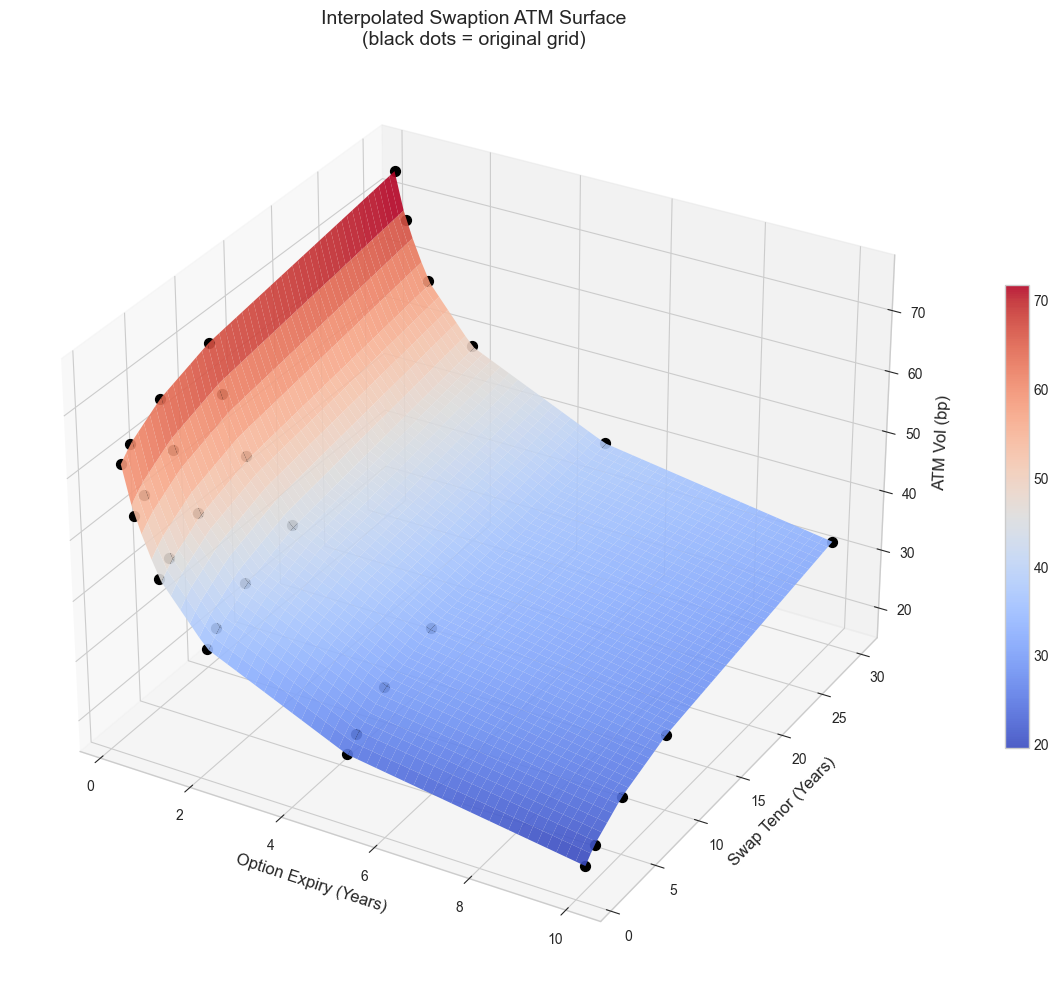

In [19]:
# Dense interpolation for swaption cube
exp_dense = np.linspace(0.25, 10.0, 50)
ten_dense = np.linspace(1.0, 30.0, 50)

atm_interp = np.zeros((len(exp_dense), len(ten_dense)))
for i, exp in enumerate(exp_dense):
    for j, ten in enumerate(ten_dense):
        atm_interp[i, j] = swaption_cube.implied_vol(exp, ten, atm_strike)

# Plot interpolated surface
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

exp_m, ten_m = np.meshgrid(exp_dense, ten_dense, indexing='ij')
surf = ax.plot_surface(exp_m, ten_m, atm_interp * 10000, cmap='coolwarm', alpha=0.9)

# Overlay original grid points
for exp in expiries:
    for ten in tenors:
        vol = swaption_cube.implied_vol(exp, ten, atm_strike)
        ax.scatter([exp], [ten], [vol * 10000], color='black', s=50, marker='o')

ax.set_xlabel('Option Expiry (Years)', fontsize=12)
ax.set_ylabel('Swap Tenor (Years)', fontsize=12)
ax.set_zlabel('ATM Vol (bp)', fontsize=12)
ax.set_title('Interpolated Swaption ATM Surface\n(black dots = original grid)', fontsize=14)
fig.colorbar(surf, ax=ax, shrink=0.5)
plt.tight_layout()
plt.show()

## 5. Integration with Pricing

These vol surfaces integrate seamlessly with the IR pricers.

In [20]:
# Example: Pricing a swaption using the vol cube
def simple_bachelier_swaption(forward, strike, expiry, vol, annuity, is_payer=True):
    """Simple Bachelier swaption pricing."""
    from scipy.stats import norm
    
    if expiry <= 0:
        return max(0, (forward - strike) * annuity) if is_payer else max(0, (strike - forward) * annuity)
    
    sigma_sqrt_t = vol * np.sqrt(expiry)
    d = (forward - strike) / sigma_sqrt_t if sigma_sqrt_t > 0 else 0
    
    if is_payer:
        price = annuity * ((forward - strike) * norm.cdf(d) + sigma_sqrt_t * norm.pdf(d))
    else:
        price = annuity * ((strike - forward) * norm.cdf(-d) + sigma_sqrt_t * norm.pdf(d))
    
    return price

# Swaption parameters
forward_rate = 0.032  # 3.2% forward swap rate
strike_rate = 0.030   # 3.0% strike
option_expiry = 2.0   # 2Y expiry
swap_tenor = 5.0      # 5Y underlying
annuity = 4.5         # ~4.5 for 5Y swap
notional = 10_000_000 # $10M

# Get vol from cube
swaption_vol = swaption_cube.implied_vol(option_expiry, swap_tenor, strike_rate)

# Price
payer_price = simple_bachelier_swaption(
    forward_rate, strike_rate, option_expiry, swaption_vol, annuity, is_payer=True
) * notional

print(f"Swaption Details:")
print(f"  Forward Rate: {forward_rate*100:.2f}%")
print(f"  Strike: {strike_rate*100:.2f}%")
print(f"  Expiry: {option_expiry:.0f}Y")
print(f"  Underlying Tenor: {swap_tenor:.0f}Y")
print(f"  Normal Vol: {swaption_vol*10000:.1f} bp")
print(f"  Notional: ${notional:,.0f}")
print(f"\n  Payer Swaption Price: ${payer_price:,.2f}")

Swaption Details:
  Forward Rate: 3.20%
  Strike: 3.00%
  Expiry: 2Y
  Underlying Tenor: 5Y
  Normal Vol: 40.6 bp
  Notional: $10,000,000

  Payer Swaption Price: $154,224.27


## Summary

This tutorial demonstrated:

1. **SwaptionVolCube**: 3D volatility structure for swaptions
   - Creation with realistic market features (term structure, smile, skew)
   - Querying and interpolation
   - Visualization (3D surfaces, heatmaps, smiles)

2. **CapFloorVolSurface**: 2D volatility structure for caps/floors
   - Hump-shaped term structure
   - Smile and skew effects
   - ATM term structure visualization

3. **Factory Functions**: Quick creation from ATM vols

4. **Flat Surfaces**: For testing and baseline pricing

5. **Integration**: Using vol surfaces with IR pricers